In [ ]:
%pip install composable

In [ ]:
# Standard imports
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Multiclass wrappers
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# Metrics

# Useful tools for averaging cv results
import composable.records as rec

# Metrics to use on the test set
# metric(y_test, y_predict)
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay



In [ ]:
(olive_oil :=
 pl.read_csv("sample_data/OliveOils.csv")
)

Area.name,palmitic,palmitoleic,strearic,oleic,linoleic,eicosanoic,linolenic
str,i64,i64,i64,i64,i64,i64,i64
"""North-Apulia""",1075,75,226,7823,672,36,60
"""North-Apulia""",1088,73,224,7709,781,31,61
"""North-Apulia""",911,54,246,8113,549,31,63
"""North-Apulia""",966,57,240,7952,619,50,78
"""North-Apulia""",1051,67,259,7771,672,50,80
…,…,…,…,…,…,…,…
"""West-Liguria""",1280,110,290,7490,790,10,10
"""West-Liguria""",1060,100,270,7740,810,10,10
"""West-Liguria""",1010,90,210,7720,970,0,0


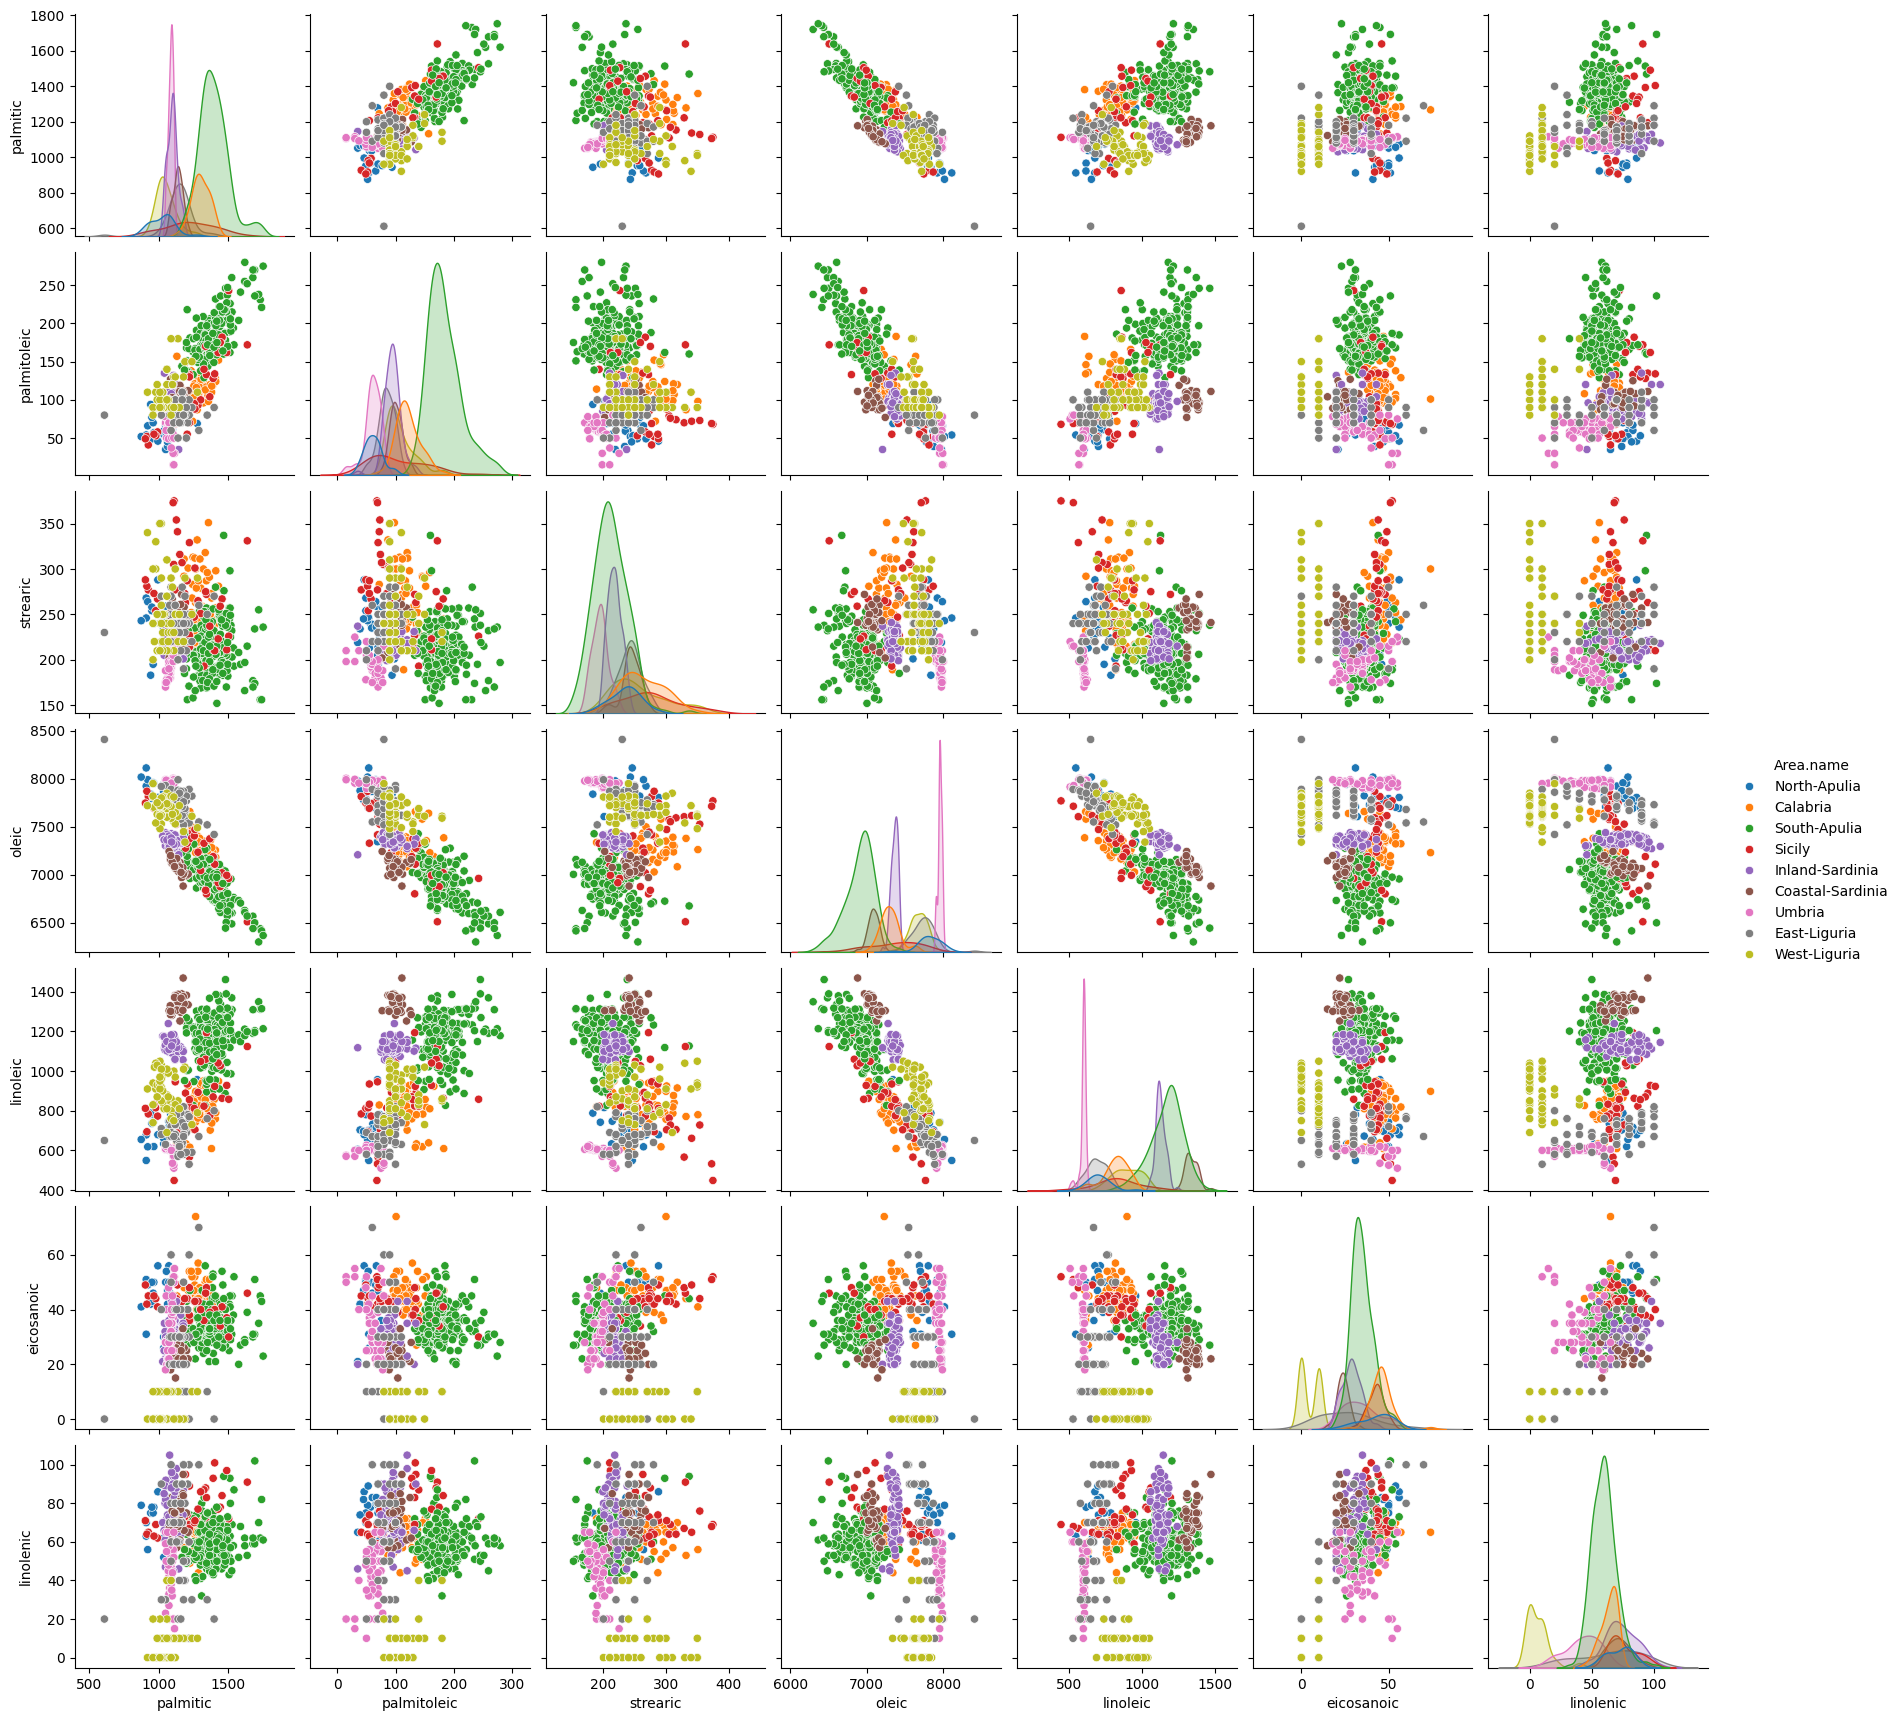

In [ ]:
sns.pairplot(olive_oil.to_pandas(), hue = 'Area.name')

In [ ]:
(X_oil :=
 olive_oil
 .drop('Area.name')
 .to_pandas()
)

,palmitic,palmitoleic,strearic,oleic,linoleic,eicosanoic,linolenic
0,1075,75,226,7823,672,36,60
1,1088,73,224,7709,781,31,61
2,911,54,246,8113,549,31,63
3,966,57,240,7952,619,50,78
4,1051,67,259,7771,672,50,80
...,...,...,...,...,...,...,...
567,1280,110,290,7490,790,10,10
568,1060,100,270,7740,810,10,10
569,1010,90,210,7720,970,0,0
570,990,120,250,7750,870,10,10


In [ ]:
(y_oil :=
 olive_oil
 .select('Area.name')
 .to_pandas()
)

,Area.name
0,North-Apulia
1,North-Apulia
2,North-Apulia
3,North-Apulia
4,North-Apulia
...,...
567,West-Liguria
568,West-Liguria
569,West-Liguria
570,West-Liguria


In [ ]:
X_train_oil, X_test_oil, y_train_oil, y_test_oil = train_test_split(X_oil, y_oil, test_size=0.3, random_state=42)

## Topic 1 - Target representation

**Options.**
1. Text label (who knew?),
2. Matrix of indicators, or
3. Sparse representation.

#### Option 1 - Text representation.

In [ ]:
y_test_oil

,Area.name
107,South-Apulia
241,South-Apulia
406,Inland-Sardinia
307,South-Apulia
436,Umbria
...,...
289,Sicily
313,South-Apulia
364,Inland-Sardinia
375,Coastal-Sardinia


In [ ]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_oil, y_train_oil.to_numpy().ravel())

log_reg.score(X_test_oil, y_test_oil.to_numpy().ravel())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8953488372093024

In [ ]:
log_reg.predict(X_test_oil)

array(['South-Apulia', 'South-Apulia', 'Inland-Sardinia', 'South-Apulia',
       'Umbria', 'Sicily', 'East-Liguria', 'South-Apulia', 'South-Apulia',
       'Calabria', 'Inland-Sardinia', 'South-Apulia', 'Coastal-Sardinia',
       'South-Apulia', 'Umbria', 'South-Apulia', 'West-Liguria',
       'North-Apulia', 'South-Apulia', 'Inland-Sardinia',
       'Inland-Sardinia', 'West-Liguria', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'West-Liguria', 'Sicily', 'West-Liguria',
       'Inland-Sardinia', 'Inland-Sardinia', 'South-Apulia', 'Calabria',
       'Umbria', 'South-Apulia', 'Inland-Sardinia', 'Calabria',
       'Inland-Sardinia', 'West-Liguria', 'Inland-Sardinia',
       'Inland-Sardinia', 'East-Liguria', 'Umbria', 'Inland-Sardinia',
       'West-Liguria', 'Umbria', 'West-Liguria', 'Umbria', 'Calabria',
       'West-Liguria', 'West-Liguria', 'Inland-Sardinia',
       'Inland-Sardinia', 'Umbria', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'East-Liguria', 'Coastal-S

In [ ]:
log_reg.score(X_test_oil, y_test_oil)

0.8953488372093024

In [ ]:
(y_score := log_reg.predict_proba(X_test_oil)
)

array([[3.44166001e-005, 1.68242888e-017, 1.11569701e-015, ...,
        9.99926701e-001, 8.58296101e-057, 3.64098452e-005],
       [2.34949944e-005, 2.12317033e-033, 4.33239943e-018, ...,
        9.99975441e-001, 2.48974404e-076, 2.88192471e-007],
       [3.18707233e-016, 2.35529634e-010, 8.81649077e-015, ...,
        7.14320072e-011, 1.00166412e-056, 1.94810822e-016],
       ...,
       [5.74673865e-009, 1.34106056e-016, 1.54489406e-007, ...,
        7.35369192e-005, 3.63743736e-053, 1.22509879e-009],
       [3.36512104e-032, 1.00000000e+000, 2.58018667e-032, ...,
        8.62750938e-025, 9.13516248e-102, 1.01472841e-028],
       [4.42290504e-004, 9.95974329e-031, 6.31993161e-011, ...,
        9.98908559e-001, 2.83968630e-058, 4.51981157e-008]])

In [ ]:
scores = pl.DataFrame(y_score)
scores.columns = log_reg.classes_

(scores
 .with_columns(total = pl.sum_horizontal(cs.float()))
)

Calabria,Coastal-Sardinia,East-Liguria,Inland-Sardinia,North-Apulia,Sicily,South-Apulia,Umbria,West-Liguria,total
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.000034,1.6824e-17,1.1157e-15,0.000002,5.2395e-19,2.3065e-7,0.999927,8.5830e-57,0.000036,1.0
0.000023,2.1232e-33,4.3324e-18,4.0444e-19,4.8300e-30,7.7603e-7,0.999975,2.4897e-76,2.8819e-7,1.0
3.1871e-16,2.3553e-10,8.8165e-15,1.0,3.6263e-18,6.2587e-12,7.1432e-11,1.0017e-56,1.9481e-16,1.0
0.083673,9.9493e-47,3.6731e-12,4.6463e-20,1.9707e-16,0.00021,0.916117,6.6725e-48,3.8929e-13,1.0
6.9125e-12,3.9503e-90,4.2213e-11,8.7433e-29,0.000061,5.6914e-15,5.3796e-16,0.999939,6.1064e-22,1.0
…,…,…,…,…,…,…,…,…,…
0.004038,1.0796e-58,0.001263,5.0617e-20,1.2667e-12,0.994694,0.000005,1.0597e-43,3.4330e-10,1.0
0.000055,9.1936e-61,1.8370e-19,1.1362e-36,2.8530e-40,0.000001,0.999944,2.0780e-91,1.0279e-11,1.0
5.7467e-9,1.3411e-16,1.5449e-7,0.999761,3.4356e-14,0.000165,0.000074,3.6374e-53,1.2251e-9,1.0


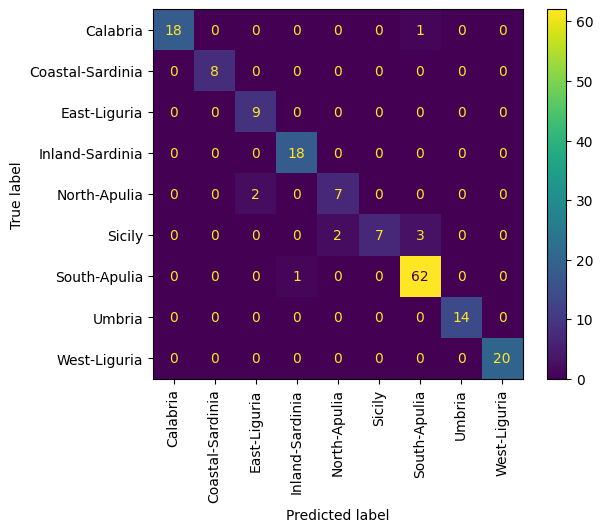

In [ ]:
plt = ConfusionMatrixDisplay.from_estimator(log_reg, X_test_oil, y_test_oil, xticks_rotation='vertical')

## <font color="red"> Exercise 1 </font>

Pick two regions of interest then do each of the following:
1. Compute a sensitivity-like measurement by computing the row-wise proportion of correct predictions, and
2. Compute a positive-predictive-power-like measurement by computing the columns-wise proportion of correct predictions.
3. Interpret each metrix in the context of the problem.

<font color = "orange">
Your work and interpretations here.
</font>

The two regions I will work with will be:
- South-Apulia, due to the sheer number of datapoints
- Sicily, due to the true label's variation in predictions.

## South Apulia
- Sensitivity = 63/63 = 1, or 100% of the time it correctly guesses a positive case
- Specificity = 63/68 = .926, or 92.6% of the time it correctly guesses a negative case


## Sicily
- Sensitivity = 5/12 = .416, or 41.6% of the time it correctly guesses a positive case
- Specificity = 5/5 = 1, or 100% of the time it correctly guesses a negative case

#### Option 2 - Indicator Matrix

**Notes.**

1. We can automate this process using `LabelBinarizer`
2. Classifiers like `LogisticRegression` must be wrapped in another class to allow this representation.
3. This output can be BIG, as it will be a $x\times k$ matrix for $n$ rows of $k$ unique classes.

In [ ]:
lb = LabelBinarizer()
lb.fit_transform(y_oil)

(y_oil_ind := lb.transform(y_oil))

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

In [ ]:
y_train_oil_ind, y_test_oil_ind

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [1, 0, 0, ..., 0, 0, 0]]),
 array([[0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0]]))

#### Option 3 - Sparse Representation

**Notes.**
1. This representation fixes the issue with the size of an indicator matrix, but becomes even more unreadable.
2. Also needs another class wrapper for classifiers like `LogisticRegression`.

In [ ]:
?sparse.csr_matrix

In [ ]:
from scipy import sparse
(y_oil_sparse := sparse.csr_matrix(y_oil_ind))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 572 stored elements and shape (572, 9)>

In [ ]:
X_train_oil, X_test_oil, y_train_oil_sparse, y_test_oil_sparse = train_test_split(X_oil, y_oil_sparse, test_size=0.3, random_state=42)


In [ ]:
y_train_oil_sparse, y_test_oil_sparse


(<Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 400 stored elements and shape (400, 9)>,
 <Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 172 stored elements and shape (172, 9)>)

## Topic 2 - `OneVsRestClassifier`

**Notes.**
1. Makes one classifier per class,
2. Each trains "class k" VS "not class k"
3. Results in $k$ classifiers, one per $k$ unique classes.

In [ ]:
(cls := OneVsRestClassifier(LogisticRegression(max_iter=1000))
)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

### Target representation - This classifier can be trained on all three target representations

#### Labels

In [ ]:
cls_lbl = OneVsRestClassifier(LogisticRegression(max_iter=1000))
cls_lbl.fit(X_train_oil, y_train_oil)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [ ]:
cls_lbl.predict(X_test_oil)

array(['South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
      

#### Indicator matrix

In [ ]:
cls_ind = OneVsRestClassifier(LogisticRegression(max_iter=1000))
cls_ind.fit(X_train_oil, y_train_oil_ind)


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [ ]:
(y_pred_ind :=
 cls_ind.predict(X_test_oil)
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
lb.inverse_transform(y_pred_ind)

array(['Calabria', 'Calabria', 'Calabria', 'Calabria', 'South-Apulia',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'South-Apulia',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'South-Apulia',
       'Calabria', 'Calabria', 'South-Apulia', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'South-Apulia', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'South-Apulia', 'Calabria',
       'Calabria', 'Calabria', 'Calabria', 'Calabria', 'Calabria',
       'Calabria', 'Calabria', 'Calabr

#### Sparse Matrix

In [ ]:
cls_sparse = OneVsRestClassifier(LogisticRegression(max_iter=1000))
cls_sparse.fit(X_train_oil, y_train_oil_sparse)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [ ]:
cls_sparse.predict(X_test_oil)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 166 stored elements and shape (172, 9)>

In [ ]:
# Don't know how to inverse transform this :()

## Topic 3 - `OneVsOneClassifier`

**Notes.**
1. Needs to wrap a classifier class,
2. Builds one classifier per pair of unique classes,
3. Buillds a total of $\frac{n*(n-1)}{2}$ classifiers, and
4. Good for classifiers where training gets expensive with more data.

In [ ]:
(cls_ovo := OneVsOneClassifier(LogisticRegression(max_iter=1000)))

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000))

In [ ]:
cls_ovo.fit(X_train_oil, y_train_oil)

cls_ovo.predict(X_test_oil)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array(['South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'Inland-Sardinia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'South-Apulia',
   

In [ ]:
cls_ovo.score(X_test_oil, y_test_oil)

0.36627906976744184

In [ ]:
cls_ovo.predict_proba(X_test_oil)

AttributeError: 'OneVsOneClassifier' object has no attribute 'predict_proba'

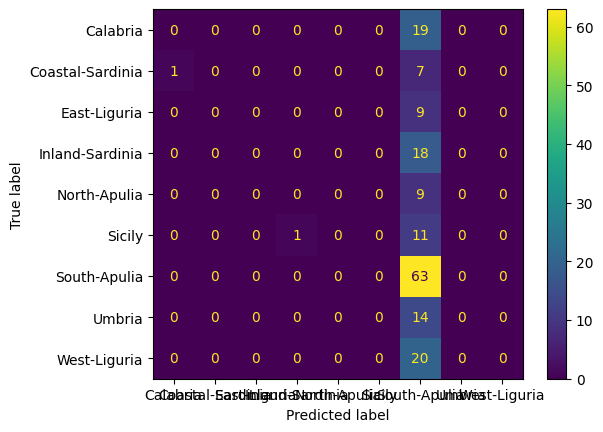

In [ ]:
ConfusionMatrixDisplay.from_estimator(cls_ovo, X_test_oil, y_test_oil)

## <font color = 'red'> Exercise 2 </font>

For each of the classic classification methods, do the following

1. Fit the method to the training labels,
2. Get the score and confusion matrix for the test data.

Repeat that process when wrapping each classifier in
1. One vs rest, and
2. One vs one.

Finally, report on the best performing approach according to the score.

In [ ]:
# We need 15 different outputs... For the rest of the four classification methods, make a score and confusion matrix for alone OVR, and OVO

# NB, ALONE
nb = GaussianNB()

nb.fit(X_train_oil, y_train_oil.to_numpy().ravel())

nb.score(X_test_oil, y_test_oil.to_numpy().ravel())

0.8895348837209303

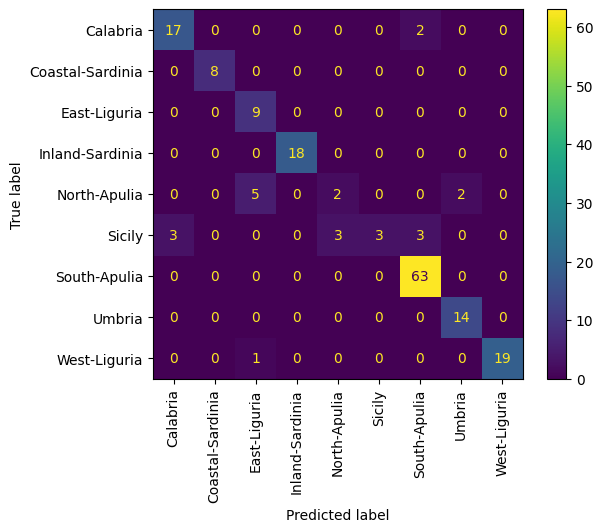

In [ ]:
plt_nb = ConfusionMatrixDisplay.from_estimator(nb, X_test_oil, y_test_oil, xticks_rotation='vertical')

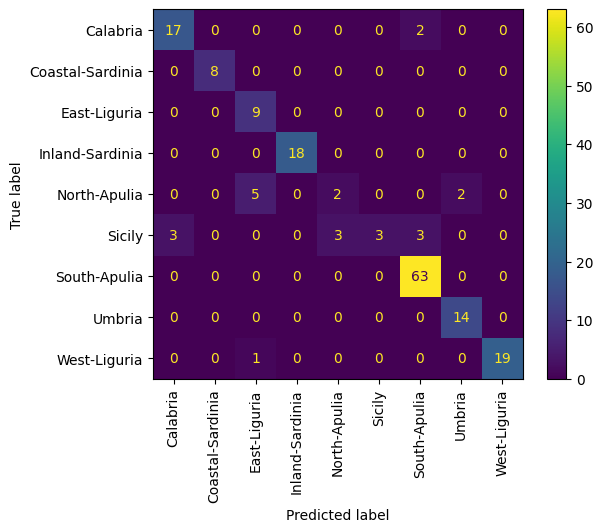

In [ ]:
# NB, OVR

cls_lbl_nb = OneVsRestClassifier(GaussianNB())
cls_lbl_nb.fit(X_train_oil, y_train_oil)


plt_nb_ovr = ConfusionMatrixDisplay.from_estimator(
    cls_lbl_nb, X_test_oil, y_test_oil, xticks_rotation='vertical'
)

In [ ]:
cls_lbl_nb.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.8895348837209303

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


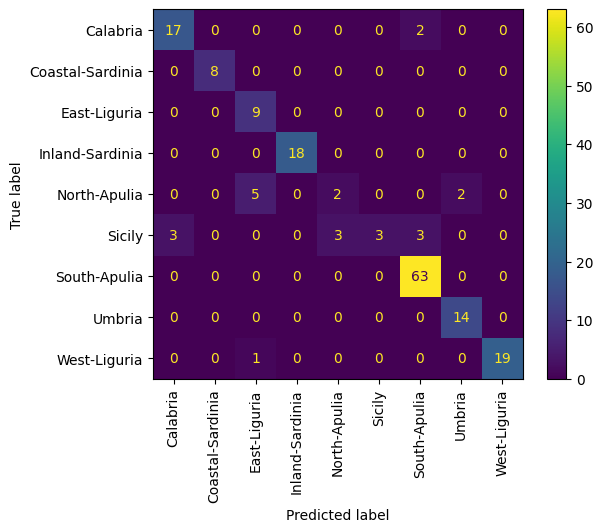

In [ ]:
# NB, OVO
cls_ovo_nb = OneVsOneClassifier(GaussianNB())
cls_ovo_nb.fit(X_train_oil, y_train_oil)


plt_nb_ovo = ConfusionMatrixDisplay.from_estimator(
    cls_ovo_nb, X_test_oil, y_test_oil, xticks_rotation='vertical'
)

In [ ]:
cls_ovo_nb.score(X_test_oil, y_test_oil)


0.3313953488372093

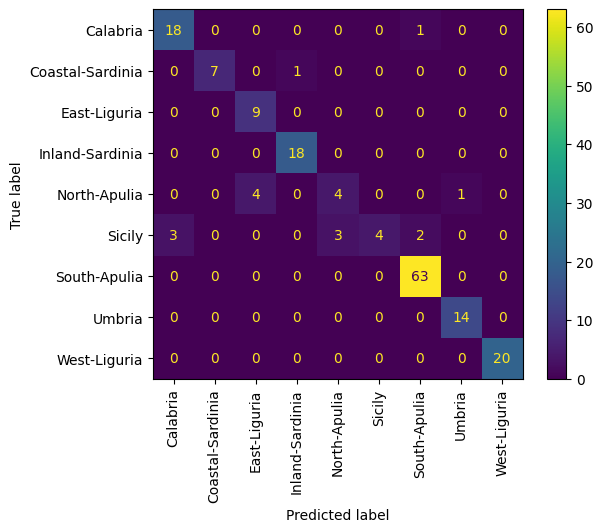

In [ ]:
# LDA, ALONE
lda = LinearDiscriminantAnalysis()

lda.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_lda = lda.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_lda, xticks_rotation='vertical'
)

In [ ]:
lda.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.9127906976744186

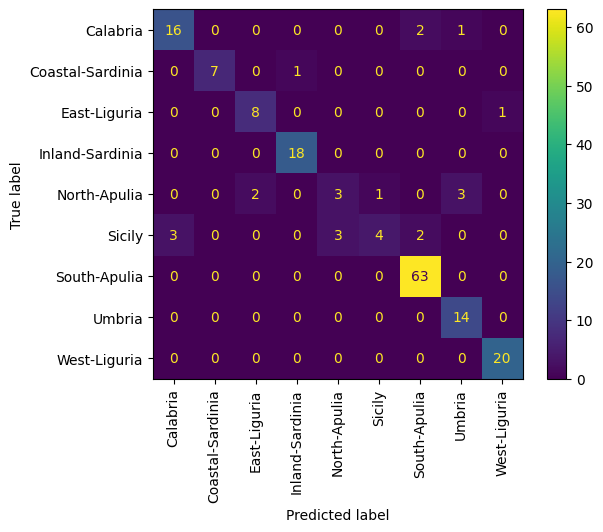

In [ ]:
# LDA, OVR
lda_ovr = OneVsRestClassifier(LinearDiscriminantAnalysis())

lda_ovr.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_lda_ovr = lda_ovr.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_lda_ovr, xticks_rotation='vertical'
)

In [ ]:
lda_ovr.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.8895348837209303

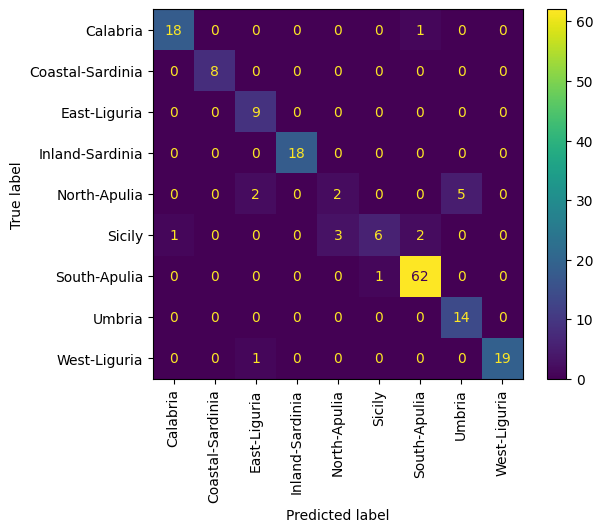

In [ ]:
# LDA, OVO
lda_ovo = OneVsOneClassifier(LinearDiscriminantAnalysis())

lda_ovo.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_lda_ovo = lda_ovo.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_lda_ovo, xticks_rotation='vertical'
)

In [ ]:
lda_ovo.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.9069767441860465

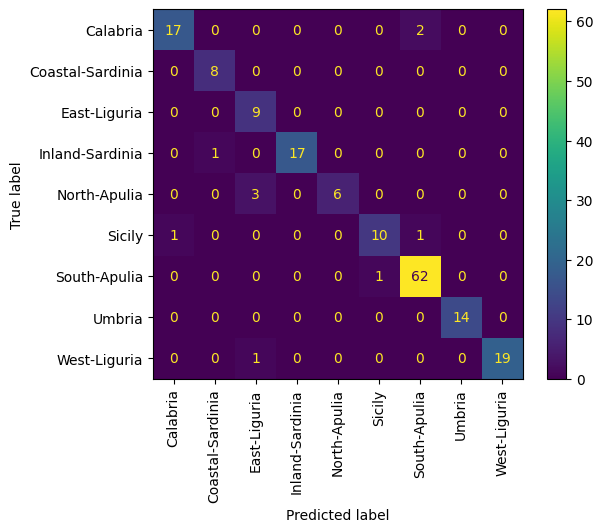

In [ ]:
# QDA, ALONE
qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_qda = qda.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_qda, xticks_rotation='vertical'
)

In [ ]:
qda.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.9418604651162791

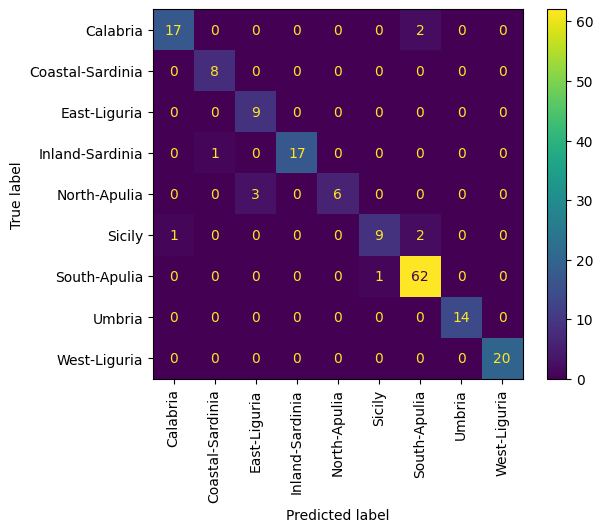

In [ ]:
# QDA, OVR
qda_ovr = OneVsRestClassifier(QuadraticDiscriminantAnalysis())

qda_ovr.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_qda_ovr = qda_ovr.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_qda_ovr, xticks_rotation='vertical'
)

In [ ]:
qda_ovr.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.9418604651162791

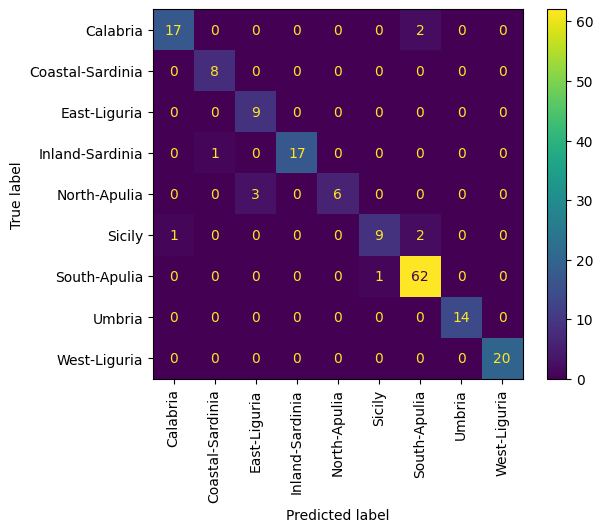

In [ ]:
# QDA, OVR
qda_ovr = OneVsRestClassifier(QuadraticDiscriminantAnalysis())

qda_ovr.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_qda_ovr = qda_ovr.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_qda_ovr, xticks_rotation='vertical'
)

In [ ]:
qda_ovr.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.9418604651162791

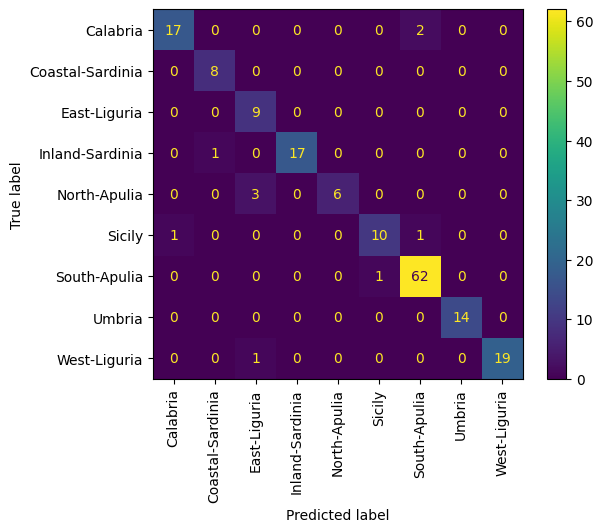

In [ ]:
# QDA, OVO
qda_ovo = OneVsOneClassifier(QuadraticDiscriminantAnalysis())

qda_ovo.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_qda_ovo = qda_ovo.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_qda_ovo, xticks_rotation='vertical'
)

In [ ]:
qda_ovo.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.9418604651162791

In [ ]:
param_grid = {
    'n_neighbors': list(range(1, 12, 2))
}

(grid_search_knn := GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
))

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7, 9, 11]},
             scoring='accuracy')

In [ ]:
grid_search_knn.fit(X_train_oil, y_train_oil.to_numpy().ravel())


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7, 9, 11]},
             scoring='accuracy')

In [ ]:
(best_k := grid_search_knn.best_params_['n_neighbors'])

3

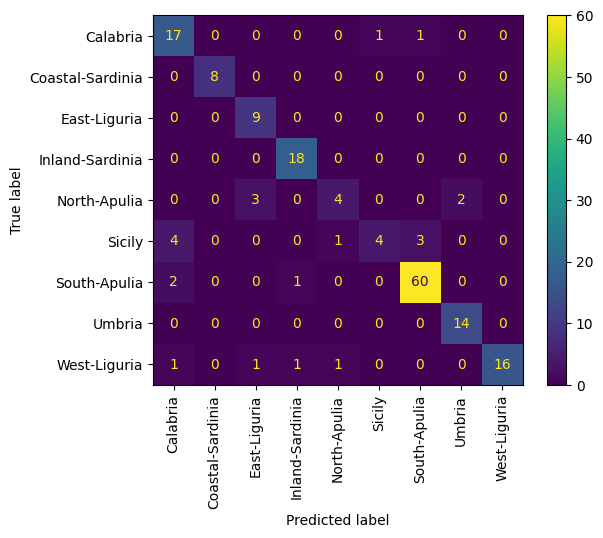

In [ ]:
# kNN, ALONE
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_oil, y_train_oil.to_numpy().ravel())

knn.score(X_test_oil, y_test_oil.to_numpy().ravel())

y_pred_knn = knn.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_knn, xticks_rotation='vertical'
)

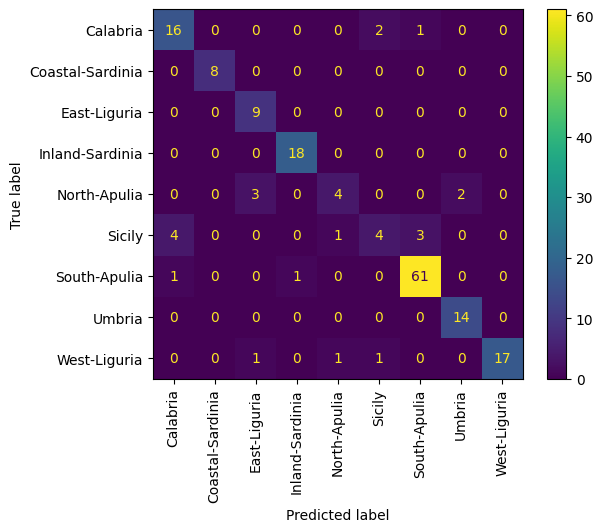

In [ ]:
# kNN, OVR
knn_ovr = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=best_k))

knn_ovr.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_knn_ovr = knn_ovr.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_knn_ovr, xticks_rotation='vertical'
)

In [ ]:
knn_ovr.score(X_test_oil, y_test_oil.to_numpy().ravel())


0.877906976744186

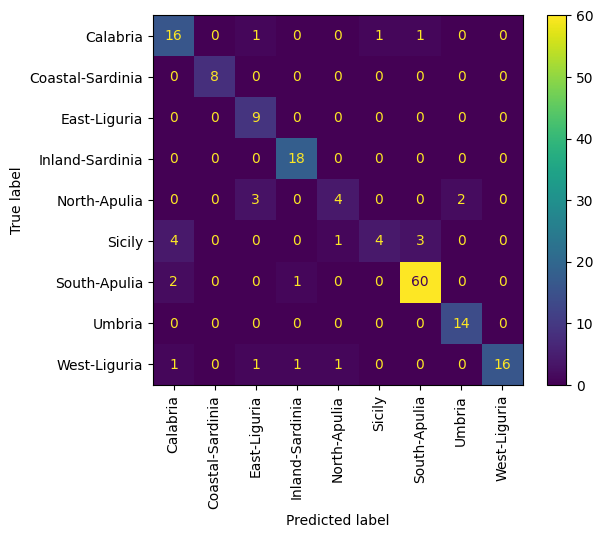

In [ ]:
# kNN, OVO
knn_ovo = OneVsOneClassifier(KNeighborsClassifier(n_neighbors=best_k))

knn_ovo.fit(X_train_oil, y_train_oil.to_numpy().ravel())

y_pred_knn_ovo = knn_ovo.predict(X_test_oil)

ConfusionMatrixDisplay.from_predictions(
    y_test_oil, y_pred_knn_ovo, xticks_rotation='vertical'
)

In [ ]:
knn_ovo.score(X_test_oil, y_test_oil.to_numpy().ravel())

0.8662790697674418